### Importing the required libraries and domain space tensor ### 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn 
import torch.autograd 
import torch.optim as optim
from IPython.display import clear_output

In [2]:
x_domain = torch.linspace(0,1,25).reshape(-1,1).requires_grad_(True)

### Setup the boundary condition ### 

In [3]:
T_naut = torch.tensor([0.0]) #setup T_0 as 0
T_1 = torch.tensor([1.0]) #setup T_1 as 1

### Setting up the Network ###
In the following block, a neural network, with 1 -> 16 - > 16 -> 1 . The acitvation function used is 

In [4]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1,32)
        self.layer2 = nn.Linear(32,32)
        self.layer3 = nn.Linear(32,1)
        self.activation = nn.Tanh()

    def forward(self,x):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        x = self.layer3(x)
        return x

model1 = PINN()
optimizer = optim.Adam(model1.parameters(),lr = 0.0001)

### define the loss function ### 
the loss function is divided into parts, 1st is the loss compared to our DE, and the second is the loss due to diobeying boundary conditions. Af ater that we run our optimizer, thats the SGD Adam optimizer

In [5]:
def compute_loss(model1,x_domain,T_naut, T_1):
    Loss_derivative = torch.tensor([0.0])
    for i in range(0,25):
        x_iter = x_domain[i];
        T = model1(x_iter)
        dT_dx, = torch.autograd.grad(T, x_iter, create_graph=True)
        d2T_dx2, = torch.autograd.grad(dT_dx , x_iter, create_graph = True)
        Loss_derivative += d2T_dx2**2
    
    Loss_derivative = Loss_derivative/25
    
    Loss_bcs = torch.tensor([0.0])
    T_naut_model = model1(x_domain[0])
    T_1_model = model1(x_domain[-1])
    Loss_bcs = (T_naut_model - T_naut)**2 + (T_1_model - T_1)**2
    
    return Loss_bcs + 10*Loss_derivative, Loss_bcs, Loss_derivative
    

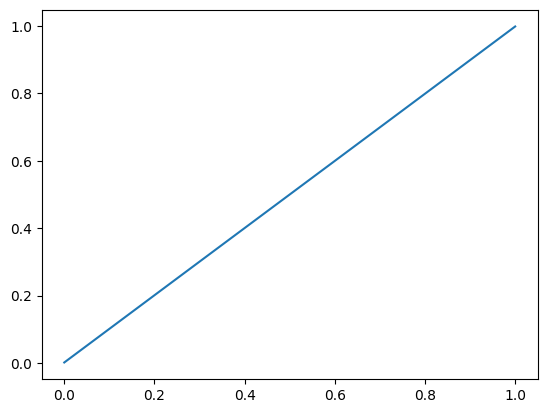

In [6]:
for epochs in range(0,2500):
    optimizer.zero_grad()
    loss, loss_bcs, loss_der = compute_loss(model1,x_domain,T_naut,T_1)
    loss.backward()
    optimizer.step()
    if epochs % 50 == 0:
        
        print(f'Epoch {epochs}, Loss: {loss.item():.4f}, DLoss: {loss_der.item()}' )
        with torch.no_grad():
            T_pred = model1(x_domain).detach().numpy()
        clear_output(wait = True)
        plt.plot(x_domain.detach().numpy(), T_pred, label=f'Epoch {epochs}')
        plt.show()


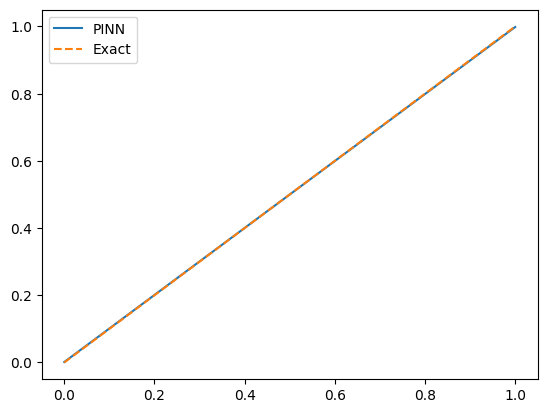

In [7]:
with torch.no_grad():
    T_pred = model1(x_domain).detach().numpy()

x_plot = x_domain.detach().numpy()
T_exact = x_plot  

plt.plot(x_plot, T_pred, label='PINN')
plt.plot(x_plot, T_exact, '--', label='Exact')
plt.legend()